# Exercises: Hypothesis Testing

**A Waiter's Tips**

The following description was retrieved from Kaggle page.

> Food servers' tips in restaurants may be influenced by many factors, including the nature of the restaurant, size of the party, and table locations in the restaurant. Restaurant managers need to know which factors matter when they assign tables to food servers. For the sake of staff morale, they usually want to avoid either the substance or the appearance of unfair treatment of the servers, for whom tips (at least in restaurants in the United States) are a major component of pay. In one restaurant, a food server recorded the following data on all customers they served during an interval of two and a half months in early 1990. The restaurant, located in a suburban shopping mall, was part of a national chain and served a varied menu. In observance of local law, the restaurant offered to seat in a non-smoking section to patrons who requested it. Each record includes a day and time, and taken together, they show the server's work schedule.

Acknowledgements The data was reported in a collection of case studies for business statistics. Bryant, P. G. and Smith, M (1995) Practical Data Analysis: Case Studies in Business Statistics. Homewood, IL: Richard D. Irwin Publishing

The dataset is also available through the Python package Seaborn.

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Here's a description of each column in the dataset:

- `total_bill`: The total bill amount, including the cost of food and drinks.
- `tip`: The tip amount given by the customer.
- `sex`: The gender of the customer (e.g., Male or Female).
- `smoker`: Whether the customer is a smoker or not (e.g., Yes or No).
- `day`: The day of the week when the transaction occurred (e.g., Sun, Sat, Thu, etc.).
- `time`: The time of day when the transaction occurred, typically categorized as Lunch or Dinner.
- `size`: The size of the party or group of customers.

**Your Task**: is to accept or reject the following hypothesis using statistical testing:

- Hypothesis $H_1$: smoking is associated with time of visit
- Hypothesis $H_2$: the bigger the group the higher the tip
- Hypothesis $H_3$: group size is different based on the time of visit
- Hypothesis $H_4$: (... come up with a hypothesis of your own ...)
- Finally, analyze if size (party size) is a **confounder**. That is, does a larger party cause a higher tip, or simply a higher bill which then leads to a higher tip?

---

## H1: Smoking is associated with time of visit

Both `smoker` and `time` are categorical variables — so we use a **Chi-square test of independence**.

- **H0**: Smoking status and time of visit are independent
- **H1**: Smoking status is associated with time of visit
- **alpha** = 0.05

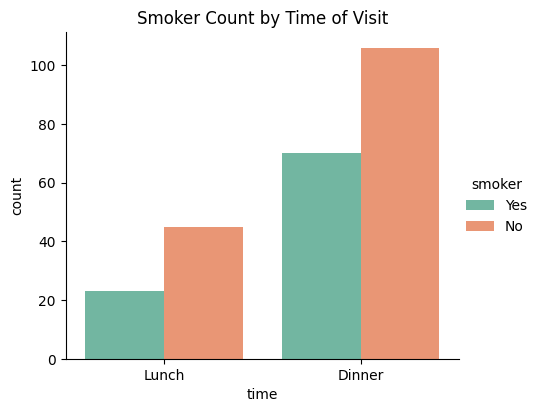

In [2]:
# Visualize the relationship first
sns.catplot(
    data=tips, x='time', hue='smoker',
    kind='count', palette='Set2', height=4, aspect=1.2
)
plt.title('Smoker Count by Time of Visit')
plt.show()

In [3]:
# Chi-square test: 2 categorical variables
alpha = 0.05

ct = pd.crosstab(tips['smoker'], tips['time'])
print(ct)

chi2, p_value, dof, expected = stats.chi2_contingency(ct)
print(f'\nChi-square: {chi2:.4f}, dof={dof}, p={p_value:.4f}')

if p_value <= alpha:
    print('Conclusion: Reject H0 — smoking is significantly associated with time of visit')
else:
    print('Conclusion: Fail to reject H0 — no significant association between smoking and time of visit')

time    Lunch  Dinner
smoker               
Yes        23      70
No         45     106

Chi-square: 0.5054, dof=1, p=0.4771
Conclusion: Fail to reject H0 — no significant association between smoking and time of visit


## H2: The bigger the group the higher the tip

`size` is numerical and `tip` is numerical — we use **Pearson correlation**.

- **H0**: No linear relationship between group size and tip amount
- **H1**: Larger groups leave higher tips
- **alpha** = 0.05

C:\Users\MA\AppData\Local\Temp\ipykernel_22872\1568932826.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(


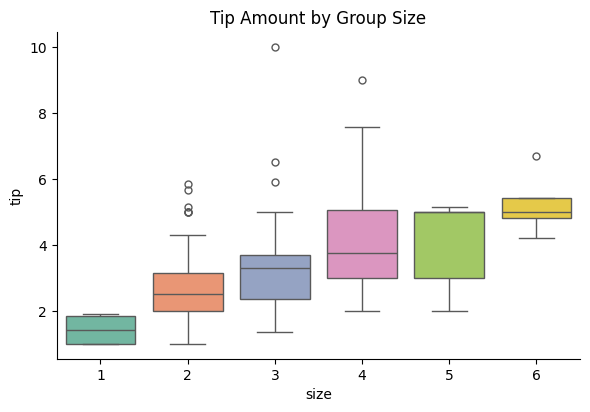

In [4]:
# Visualize
sns.catplot(
    data=tips, x='size', y='tip',
    kind='box', palette='Set2', height=4, aspect=1.5
)
plt.title('Tip Amount by Group Size')
plt.show()

In [7]:
# Pearson correlation: 2 numerical variables
alpha = 0.05

r, p_value = stats.pearsonr(tips['size'], tips['tip'])
print(f'Pearson r={r}, p={p_value}')

if p_value <= alpha:
    print('Conclusion: there are no relationships  between group size and tip amount')
else:
    print('Conclusion: Fail to reject H0 — no significant relationship')

Pearson r=0.48929877523035725, p=4.3005433272249666e-16
Conclusion: there are no relationships  between group size and tip amount


## H3: Group size is different based on time of visit

`time` has 2 groups (Lunch/Dinner) and `size` is numerical → **independent t-test**.

- **H0**: Average group size is the same at Lunch and Dinner
- **H1**: Group size differs between Lunch and Dinner
- **alpha** = 0.05

C:\Users\MA\AppData\Local\Temp\ipykernel_22872\240785259.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(


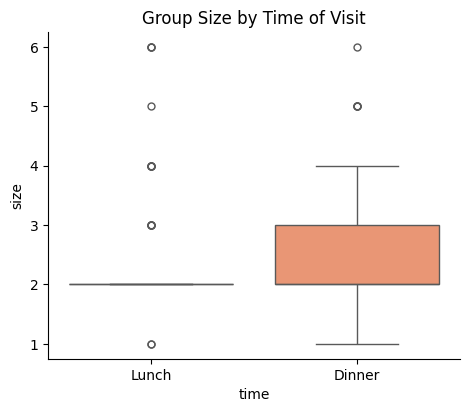

In [9]:
sns.catplot(
    data=tips, x='time', y='size',
    kind='box', palette='Set2', height=4, aspect=1.2
)
plt.title('Group Size by Time of Visit')
plt.show()



In [11]:
alpha = 0.05

lunch  = tips.loc[tips['time'] == 'Lunch',  'size']
dinner = tips.loc[tips['time'] == 'Dinner', 'size']

t_stat, p_value = stats.ttest_ind(lunch, dinner)
print(f't-statistic: {t_stat}')
print(f'p-value: {p_value}')

if p_value <= alpha:
    print('Conclusion: group size differs significantly between Lunch and Dinner')
else:
    print('Conclusion: no significant difference in group size by time')

t-statistic: -1.6173673798749002
p-value: 0.10710169330429037
Conclusion: no significant difference in group size by time


## H4: Male customers leave higher tips than female customers

- **H0**: No difference in tip amount between Male and Female customers
- **H1**: Male customers tip more than Female customers
- **alpha** = 0.05

C:\Users\MA\AppData\Local\Temp\ipykernel_22872\3054945337.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(


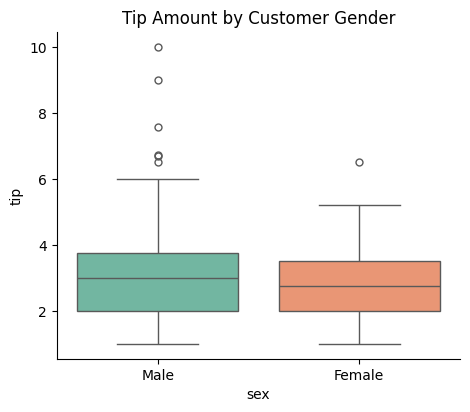

In [15]:
sns.catplot(
    data=tips, x='sex', y='tip',
    kind='box', palette='Set2', height=4, aspect=1.2
)
plt.title('Tip Amount by Customer Gender')
plt.show()


In [19]:
alpha = 0.05

male   = tips.loc[tips['sex'] == 'Male',   'tip']
female = tips.loc[tips['sex'] == 'Female', 'tip']

t_stat, p_value = stats.ttest_ind(male, female)
print(f't-statistic: {t_stat}')
print(f'p-value: {p_value}')

if p_value <= alpha:
    print('Conclusion: significant difference in tips between Male and Female')
else:
    print('Conclusion:  no significant difference in tips by gender')

t-statistic: 1.387859705421269
p-value: 0.16645623503456755
Conclusion:  no significant difference in tips by gender


**Interpretation**: Despite males having a slightly higher mean tip, the difference is not statistically significant. Gender alone is not a reliable predictor of tip amount.

## Confounder Analysis: Is party size the real cause of higher tips?

We found in H2 that larger groups tip more. But is that because:
- **Direct**: bigger party → higher tip?
- **Indirect**: bigger party → higher bill → higher tip (size is a **confounder**)?

We test all three correlations to see which chain is stronger.

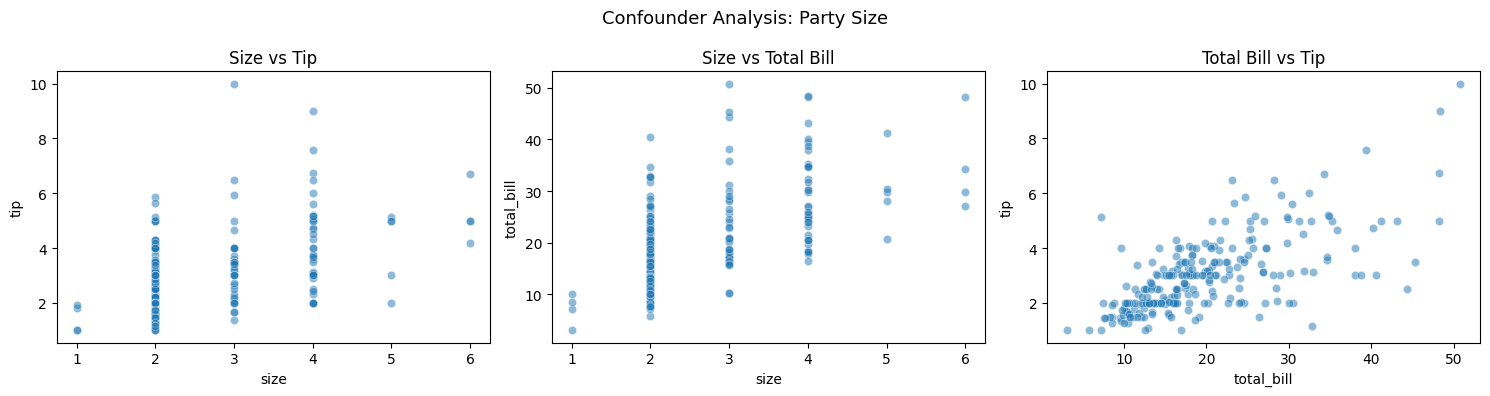

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(data=tips, x='size', y='tip',        alpha=0.5, ax=axes[0])
axes[0].set_title('Size vs Tip')

sns.scatterplot(data=tips, x='size', y='total_bill', alpha=0.5, ax=axes[1])
axes[1].set_title('Size vs Total Bill')

sns.scatterplot(data=tips, x='total_bill', y='tip',  alpha=0.5, ax=axes[2])
axes[2].set_title('Total Bill vs Tip')

plt.suptitle('Confounder Analysis: Party Size', fontsize=13)
plt.tight_layout()
plt.show()

In [24]:
r1, p1 = stats.pearsonr(tips['size'],       tips['tip'])
r2, p2 = stats.pearsonr(tips['size'],       tips['total_bill'])
r3, p3 = stats.pearsonr(tips['total_bill'], tips['tip'])

print(f'size to  tip:        r={r1} , p={p1}')
print(f'size to total_bill: r={r2}, p={p2}')
print(f'total_bill to tip:        r={r3}, p={p3}')

size to  tip:        r=0.48929877523035725 , p=4.3005433272249666e-16
size to total_bill: r=0.5983151309049014, p=4.393510142477113e-25
total_bill to tip:        r=0.6757341092113647, p=6.6924706468631854e-34




The evidence points to `total_bill` as the **mediator** (confounder):
- Bigger parties generate a higher bill (r=0.598)
- Higher bills lead to higher tips (r=0.676)
- The direct size   tip correlation (r=0.489) is weaker than both

**Conclusion**: Party size does not directly cause higher tips. Instead, larger parties order more food which raises the bill, and customers tend to tip proportionally to the bill. `total_bill` is the true driver of tip amount — `size` is a confounder.